# Receptive field 탐색하기

## 0. Requirements

In [1]:
import l3ac
import torch
import torchaudio

from utils.convert import convert_audio

/opt/conda/envs/l3ac/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Output()

In [ ]:
l3ac.list_models()

['ablation',
 '1kbps',
 '3kbps',
 '3kbps_music',
 '1k5bps',
 '3kbps_music_infer',
 '0k75bps']

In [3]:
LOCAL_AUDIO_PATH = "/workspace/codec/L3AC/data/assets/input_audio_0.wav"

## 1. Load models

In [ ]:
torch.cuda.is_available()

True

In [ ]:
device = torch.device("cpu")

In [ ]:
96/16000

0.006

In [6]:
# --- Local checkpoint config ---
CKPT_PATH = "/workspace/codec/L3AC/output/checkpoint/60119071448_UX5E2.pt"  # <-- set your local checkpoint path
CONFIG_NAME = '3kbps_music_infer'  # pick a valid config (e.g., 'debug')

In [7]:
# --- Load L3AC from local single-file checkpoint ---
import torch

model = l3ac.get_model(CONFIG_NAME)
print(f"loaded codec and codec sample rate: {model.config.sample_rate}")
print("model info: ", l3ac.get_model_info(model.network))

state = torch.load(CKPT_PATH, map_location="cpu")
model.network.load_state_dict(state, strict=False)

model.network.to(device=device)
model.network.eval()

DEBUG: Looking for config at: /workspace/codec/L3AC/src/model/exp/configs/3kbps_music_infer.toml

DEBUG: Does file exist? True

loaded codec and codec sample rate: 16000

model info:  {'macs': '1.64 GMac', 'params': '10.31 M', 'codebook_size': 250047, 'frame_rate': 166.66666666666666, 
'bps': 2988.6399617499583, 'receptive_field': 2.4000000000000004}

EnCodec(
  (encoder): Encoder(
    (blocks): Sequential(
      (0): V3FirstBlock(
        (blocks): ModuleList(
          (0-4): 5 x Sequential(
            (0): TrendPool()
            (1): CausalConv1d(
              (conv): ParametrizedConv1d(
                1, 4, kernel_size=(7,), stride=(1,)
                (parametrizations): ModuleDict(
                  (weight): ParametrizationList(
                    (0): _WeightNorm()
                  )
                )
              )
            )
          )
        )
        (conv_1): ParametrizedConv1d(
          20, 80, kernel_size=(1,), stride=(1,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
        (act): GELU(approximate='none')
        (conv_2): ParametrizedConv1d(
          81, 24, kernel_size=(1,), stride=(1,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _Weig

window size가 500일 때, \
`receptive_field = mc.en_coder_window_size / frame_rate`\
=> local transformer가 한 번에 얼마나 긴 context를 볼 것인지를 나타냄.

# 2. Load input waveform

In [8]:
# --- Load input waveform ---
wav, sr = torchaudio.load(LOCAL_AUDIO_PATH)
print(f"Original audio sr: {sr}, shape: {wav.shape}")

target_sr = model.config.sample_rate
wav = convert_audio(wav, sr, target_sr, 1).to(device)#[:, :int(target_sr*4)] # 중요: 길이 맞추기
print(f"Converted audio sr: {target_sr}, shape: {wav.shape}")
wav.requires_grad = True  # 중요!! input gradient 추적

Original audio sr: 32000, shape: torch.Size([1, 320000])

Converted audio sr: 16000, shape: torch.Size([1, 160000])

In [11]:
81920/64/16000

0.08

In [9]:
# --- Forward pass ---
output_dict = model.network(wav)

# `forward`가 반환한 딕셔너리에서 'generated_audio'를 추출
audio_out = output_dict['generated_audio']

# decoder input 또한 gradient 출력하기 위함
decoder_input = output_dict['hidden_feature']['quantized_feature']
decoder_input.retain_grad() # grad 속성에 같이 저장해준다..!

# (디버깅용) 입력과 출력 길이가 같은지 확인
print(f"Input shape: {wav.shape}, Output shape: {audio_out.shape}")
if wav.shape[-1] != audio_out.shape[-1]:
    print("Warning: Input and Output shapes mismatch!")

Input shape: torch.Size([1, 160000]), Output shape: torch.Size([1, 160000])

In [10]:
decoder_input.shape

torch.Size([1, 128, 1667])

In [ ]:
frame_idx = -1 # 마지막 프레임
lat_scalar = decoder_input[:, :, frame_idx].pow(2).sum()

In [ ]:
grad = torch.autograd.grad(lat_scalar, wav, retain_graph=True)[0].abs().squeeze(0).squeeze(0)
grad

tensor([0.1361, 0.0102, 0.0349,  ..., 0.0000, 0.0000, 0.0000])

In [13]:
grad.nonzero()

tensor([[     0],
        [     1],
        [     2],
        ...,
        [159934],
        [159935],
        [159936]])

In [14]:
# --- Select t-th output sample ---
t = 10000  # 보고 싶은 시점 인덱스
target = torch.zeros_like(audio_out[:, t])
loss = (audio_out[:, t] - target).pow(2).mean()

# 이전에 계산된 그래디언트 초기화
model.network.zero_grad()
wav.grad = None

print("Running backward pass...")
loss.backward()

Running backward pass...

In [15]:
%xmode Plain

Exception reporting mode: Plain

In [16]:
# --- Check Receptive Field ---
if wav.grad is None:
    print("Error: wav.grad is None. Graph is broken.")
    print("  -> (Is `model.train()` correctly called?)")
else:
    grad = wav.grad.abs().squeeze().cpu()
    nonzero_idx = torch.where(grad > 1e-4)[0]

    if len(nonzero_idx) == 0:
        print("Error: Gradient is zero everywhere.")
    else:
        rf_start = nonzero_idx[0].item()
        rf_end = nonzero_idx[-1].item()
        rf_samples = rf_end - rf_start + 1
        print(f"--- Results ---")
        print(f"Receptive field (samples): {rf_samples}, ({rf_start} ~ {rf_end})")
        print(f"Time window: {rf_samples / target_sr:.3f} seconds")

        if rf_samples == wav.shape[-1]:
             print("Info: Receptive field is 'Global' (covers the entire input).")

--- Results ---

Receptive field (samples): 87512, (0 ~ 87511)

Time window: 5.470 seconds

In [17]:
loss

tensor(0.0214, grad_fn=<MeanBackward0>)

In [18]:
grad

tensor([0.0009, 0.0011, 0.0020,  ..., 0.0000, 0.0000, 0.0000])

In [19]:
len(nonzero_idx)

8535

In [20]:
max(grad)

tensor(0.0598)

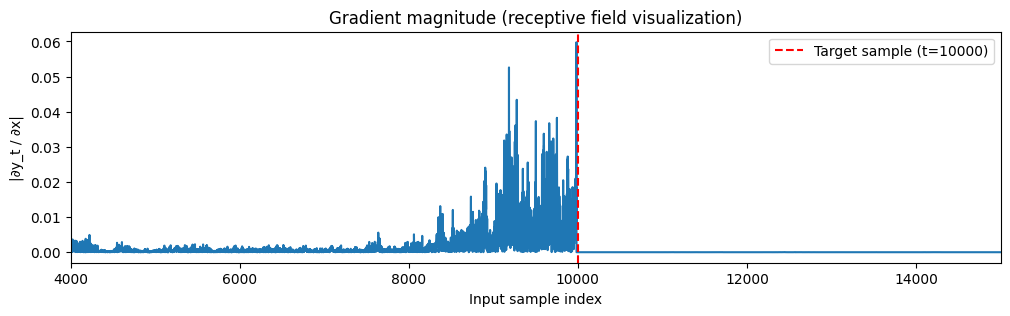

In [21]:
# --- Optional: 시각화 ---
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 3))
plt.plot(grad)
plt.title("Gradient magnitude (receptive field visualization)")
plt.xlabel("Input sample index")
plt.ylabel("|∂y_t / ∂x|")
plt.xlim(4000, 15000)

# Add a vertical line at x=1000
plt.axvline(x=t, color='r', linestyle='--', label=f'Target sample (t={t})')
plt.legend()

plt.show()

## Quantized embedding에 대한 receptive field

In [ ]:
decoder_input.shape

torch.Size([1, 128, 1667])

In [ ]:
9*16000/1716

83.91608391608392

In [ ]:
# ⭐️ "decoder 입력"의 그래디언트 확인
if decoder_input.grad is not None:
    print("--- Decoder Input Gradient ---")
    # .grad의 shape은 decoder_input의 shape과 동일합니다.
    grad_q = decoder_input.grad.abs().cpu()
    print(f"Gradient shape: {grad_q.shape}")

    # 그래디언트가 0이 아닌 요소들의 인덱스를 확인
    nonzero_idx_q = torch.where(grad_q > 1e-5)

    if len(nonzero_idx_q[0]) > 0:
        print(f"Total non-zero grad elements: {len(nonzero_idx_q[0])}")
        t_axis = -1 # grdient shape [B, C, T] : [1,128,1716]
        rf_start_q = nonzero_idx_q[t_axis].min().item()
        rf_end_q = nonzero_idx_q[t_axis].max().item()
        print(f"Quantized RF (frames): {rf_end_q - rf_start_q + 1}, ({rf_start_q} ~ {rf_end_q})")
        print(f"Quantized RF (seconds): {(rf_end_q - rf_start_q + 1) / target_sr:.3f}")
    else:
        print("Quantized RF: Gradient is zero.")
else:
    print("\nError: decoder_input.grad is None.")

--- Decoder Input Gradient ---

Gradient shape: torch.Size([1, 128, 1667])

Total non-zero grad elements: 3786

Quantized RF (frames): 1667, (0 ~ 1666)

Quantized RF (seconds): 0.104

## Visualize Quantized Embedding Gradient

In [ ]:
# We need to figure out the downsampling factor of the encoder
# This can be done by looking at the strides in the encoder layers
# From the model summary, the strides are 6, 5, and 3.
# Total downsampling factor = 6 * 5 * 3 = 90
# 여기에 encoder_compression rate 3을 곱해줌..

downsampling_factor = 16000//166 # Based on encoder strides in the model summary

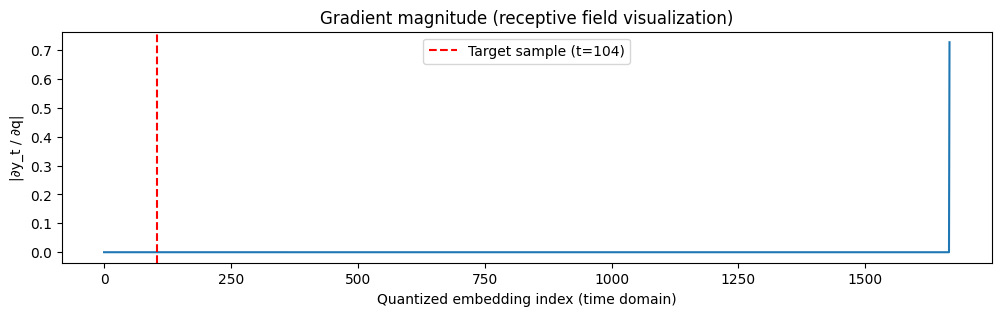

In [24]:
# --- 시각화 ---
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 3))
plt.plot(grad_q.squeeze()[-1])
plt.title("Gradient magnitude (receptive field visualization)")
plt.xlabel("Quantized embedding index (time domain)") # 실제로는 1716까지 있음 (시간 축 length: 1716)
plt.ylabel("|∂y_t / ∂q|")
#plt.xlim(100, 500)

# Add a vertical line
plt.axvline(x=t//downsampling_factor, color='r', linestyle='--', label=f'Target sample (t={t//downsampling_factor})')
plt.legend()

plt.show()

## Map Quantized RF to Input Samples

downampling factor 270으로 바꿔서 계산..? 출력을 보면 90이 맞는 것 같음

In [36]:
# Quantized RF indices (assuming rf_start_q and rf_end_q are already computed)
quantized_rf_start_frame = rf_start_q
quantized_rf_end_frame = rf_end_q

# Calculate the corresponding input sample indices
# Each quantized frame corresponds to 'downsampling_factor' input samples
# The target output sample 't' corresponds to a quantized frame
# We need to find which quantized frame 't' corresponds to.
# From the model info, frame_rate is 59.259, which means each frame corresponds to sample_rate / frame_rate = 16000 / 59.259 = ~270.
# However, a more precise way is to use the total downsampling factor.
# The quantized frame index corresponding to input sample 't' is approximately t / downsampling_factor.

# Let's find the quantized frame index that the target output sample 't' (10000) corresponds to.
# The output sample index `t` is related to the quantized frame index `q_t` by `t = q_t * downsampling_factor + offset`.
# We can approximate `q_t = t / downsampling_factor`.
approx_target_quantized_frame = t // downsampling_factor # Using integer division

print(f"Approximate quantized frame for target input sample {t}: {approx_target_quantized_frame}")

# The non-zero quantized RF frames are rf_start_q to rf_end_q.
# To map these back to input samples, we multiply by the downsampling factor.
# This gives a range of input samples for each quantized frame.
# The range of input samples corresponding to the quantized RF is approximately:
input_rf_start = quantized_rf_start_frame * downsampling_factor
input_rf_end = (quantized_rf_end_frame + 1) * downsampling_factor - 1 # +1 because end_frame is inclusive, -1 for zero-based indexing

print(f"Approximate input sample range corresponding to Quantized RF ({rf_start_q} ~ {rf_end_q}) => {input_rf_start} ~ {input_rf_end}")
print(f"Approximate input RF duration: {(input_rf_end - input_rf_start + 1) / target_sr:.3f} seconds")

Approximate quantized frame for target input sample 10000: 104

Approximate input sample range corresponding to Quantized RF (0 ~ 1666) => 0 ~ 160031

Approximate input RF duration: 10.002 seconds

## 마지막 frame이 wav의 어디를 보는가

Target Quantized Frame index: 1666

Running backward pass for Encoder Receptive Field...

--- Encoder Receptive Field Results ---

Target Frame (Quantized): 1666

Receptive Field Range (Input Samples): 15 ~ 159936

Receptive Field Length: 159922 samples

Receptive Field Duration: 9.9951 seconds

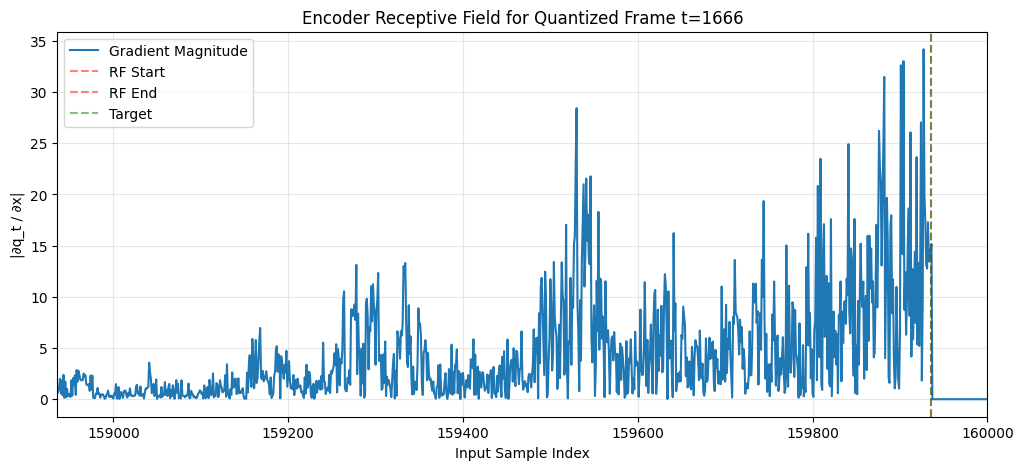

In [25]:
import matplotlib.pyplot as plt

# --- Calculate Encoder Receptive Field (d(Quantized Embedding) / d(Input)) ---
downsampling_factor = 16000//166  # Encoder의 총 다운샘플링 비율

# 1. Gradient 추적을 위해 입력 wav 설정
if not wav.requires_grad:
    wav.requires_grad = True

# 2. Forward Pass 수행
# 이미 수행된 output_dict가 있다면 재사용해도 되지만, 
# 그래프가 끊겨있을 수 있으므로 안전하게 다시 수행합니다.
output_dict = model.network(wav)
quantized_feature = output_dict['hidden_feature']['quantized_feature'] # Shape: [B, C, T_q]

# 3. 타겟 시점(t_q) 설정
# 앞서 계산한 approx_target_quantized_frame (예: 111) 또는 임의의 시점을 지정합니다.
t_q = quantized_feature.shape[-1]-1  # 마지막 프레임
if t_q >= quantized_feature.shape[-1]:
    t_q = quantized_feature.shape[-1] // 2 # 범위를 벗어나면 중간값으로 설정

print(f"Target Quantized Frame index: {t_q}")

# 4. Loss 정의 및 Backward
# 해당 시점(t_q)의 모든 채널 feature 값의 합을 구합니다.
# 이 값에 영향을 주는 입력 샘플들을 찾기 위해 역전파를 수행합니다.
target_loss = quantized_feature[0, :, t_q].sum()

model.network.zero_grad()
if wav.grad is not None:
    wav.grad = None

print("Running backward pass for Encoder Receptive Field...")
target_loss.backward()

# 5. Gradient 분석 (Receptive Field 확인)
# wav.grad: [1, samples] -> [samples]
grad_enc = wav.grad.abs().squeeze().cpu()

# 0이 아닌(유의미한) 그래디언트 구간 찾기
threshold = 1e-2
nonzero_idx_enc = torch.where(grad_enc > threshold)[0]

if len(nonzero_idx_enc) == 0:
    print("Error: Gradient is zero everywhere.")
else:
    rf_start_enc = nonzero_idx_enc.min().item()
    rf_end_enc = nonzero_idx_enc.max().item()
    rf_len_enc = rf_end_enc - rf_start_enc + 1
    
    print(f"--- Encoder Receptive Field Results ---")
    print(f"Target Frame (Quantized): {t_q}")
    print(f"Receptive Field Range (Input Samples): {rf_start_enc} ~ {rf_end_enc}")
    print(f"Receptive Field Length: {rf_len_enc} samples")
    print(f"Receptive Field Duration: {rf_len_enc / target_sr:.4f} seconds")

    # 6. 시각화 (Matplotlib)
    plt.figure(figsize=(12, 5))
    plt.plot(grad_enc.numpy(), label='Gradient Magnitude')
    
    # 시각화 범위를 target 주변으로 확대
    target = t_q * downsampling_factor
    margin = 1000
    plt.xlim(max(0, target - margin), min(len(grad_enc), target + margin))
    
    plt.title(f"Encoder Receptive Field for Quantized Frame t={t_q}")
    plt.xlabel("Input Sample Index")
    plt.ylabel("|∂q_t / ∂x|")
    
    # RF 범위 표시
    plt.axvline(x=rf_start_enc, color='r', linestyle='--', alpha=0.5, label='RF Start')
    plt.axvline(x=rf_end_enc, color='r', linestyle='--', alpha=0.5, label='RF End')
    plt.axvline(x=target, color='g', linestyle='--', alpha=0.5, label='Target')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 특정 프레임이 wav의 어디를 보는가

Target Quantized Frame index: 103

Running backward pass for Encoder Receptive Field...

--- Encoder Receptive Field Results ---

Target Frame (Quantized): 103

target sample : 10000

Receptive Field Range (Input Samples): 0 ~ 9888

Receptive Field Length: 9889 samples

Receptive Field Duration: 0.6181 seconds

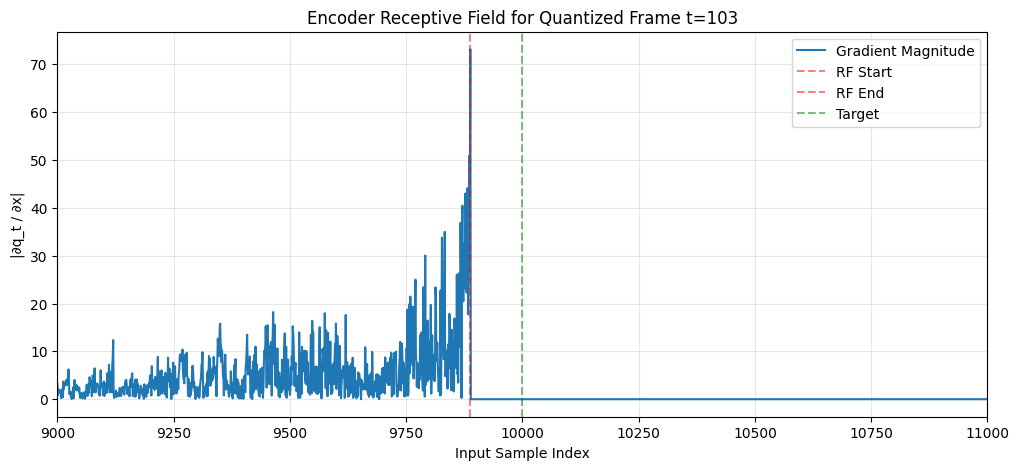

In [26]:
import matplotlib.pyplot as plt

# --- Calculate Encoder Receptive Field (d(Quantized Embedding) / d(Input)) ---
downsampling_factor = 16000//166  # Encoder의 총 다운샘플링 비율

# 1. Gradient 추적을 위해 입력 wav 설정
if not wav.requires_grad:
    wav.requires_grad = True

# 2. Forward Pass 수행
# 이미 수행된 output_dict가 있다면 재사용해도 되지만, 
# 그래프가 끊겨있을 수 있으므로 안전하게 다시 수행합니다.
output_dict = model.network(wav)
quantized_feature = output_dict['hidden_feature']['quantized_feature'] # Shape: [B, C, T_q]

# 3. 타겟 시점(t_q) 설정
# 앞서 계산한 approx_target_quantized_frame (예: 111) 또는 임의의 시점을 지정합니다.
target = 10000
t_q = (target+1)//downsampling_factor-1
if t_q >= quantized_feature.shape[-1]:
    t_q = quantized_feature.shape[-1] // 2 # 범위를 벗어나면 중간값으로 설정

print(f"Target Quantized Frame index: {t_q}")

# 4. Loss 정의 및 Backward
# 해당 시점(t_q)의 모든 채널 feature 값의 합을 구합니다.
# 이 값에 영향을 주는 입력 샘플들을 찾기 위해 역전파를 수행합니다.
target_loss = quantized_feature[0, :, t_q].sum()

model.network.zero_grad()
if wav.grad is not None:
    wav.grad = None

print("Running backward pass for Encoder Receptive Field...")
target_loss.backward()

# 5. Gradient 분석 (Receptive Field 확인)
# wav.grad: [1, samples] -> [samples]
grad_enc = wav.grad.abs().squeeze().cpu()

# 0이 아닌(유의미한) 그래디언트 구간 찾기
threshold = 1e-3
nonzero_idx_enc = torch.where(grad_enc > threshold)[0]

if len(nonzero_idx_enc) == 0:
    print("Error: Gradient is zero everywhere.")
else:
    rf_start_enc = nonzero_idx_enc.min().item()
    rf_end_enc = nonzero_idx_enc.max().item()
    rf_len_enc = rf_end_enc - rf_start_enc + 1
    
    print(f"--- Encoder Receptive Field Results ---")
    print(f"Target Frame (Quantized): {t_q}")
    print(f"target sample : {target}")
    print(f"Receptive Field Range (Input Samples): {rf_start_enc} ~ {rf_end_enc}")
    print(f"Receptive Field Length: {rf_len_enc} samples")
    print(f"Receptive Field Duration: {rf_len_enc / target_sr:.4f} seconds")

    # 6. 시각화 (Matplotlib)
    plt.figure(figsize=(12, 5))
    plt.plot(grad_enc.numpy(), label='Gradient Magnitude')
    
    # 시각화 범위를 target 주변으로 확대
    
    margin = 1000
    plt.xlim(max(0, target - margin), min(len(grad_enc), target + margin))
    
    plt.title(f"Encoder Receptive Field for Quantized Frame t={t_q}")
    plt.xlabel("Input Sample Index")
    plt.ylabel("|∂q_t / ∂x|")
    
    # RF 범위 표시
    plt.axvline(x=rf_start_enc, color='r', linestyle='--', alpha=0.5, label='RF Start')
    plt.axvline(x=rf_end_enc, color='r', linestyle='--', alpha=0.5, label='RF End')
    plt.axvline(x=target, color='g', linestyle='--', alpha=0.5, label='Target')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [100]:
1600/16000

0.1

In [30]:
39/500

0.078